# ⚗️ **【Lab】使用 PyTorch 构建 CNN 模型：识别 MNIST 手写数字**

## 🎯 **1. 示例目标**

- 部署对应版本的 NVIDIA CUDA 环境
  - OS 环境：Win11
  - GPU 硬件：NVIDIA RTX 2000 Ada Generation Labtop GPU
- 基于 MNIST 数据集训练与测试 CNN 卷积神经网络
  - PyTorch 模型：`GPU` 版本
  - TensorFlow 模型：`CPU` 版本
  - 🚨 说明：此处的 `GPU` 版本是指调用 CUDA 框架，PyTorch 与 TensorFlow 本身同时支持 CPU 与 GPU，只是在数据加载与模型调用上存在差异。
- 使用 Flask 应用部署模型
- 用户使用 HTML 手写板与 Flask 应用交互实现手写数字识别

## 🚀 **2. 启用本地 NVIDIA CUDA**

此次实验于 Win11 平台中做测试，GPU 硬件为 `NVIDIA RTX 2000 Ada`。因此，尝试启用 NVIDIA CUDA 与 PyTorch 加速 CNN 模型的训练。

## 🪛 **3. 如何为 NVIDIA RTX 2000 Ada 安装 CUDA 开发工具？**

- [此显卡](https://www.nvidia.cn/content/dam/en-zz/Solutions/design-visualization/rtx-2000/proviz-rtx-2000-ada-datasheet-zhCN-3169852-print.pdf) 可支持 CUDA 11.6。可在 [CUDA Toolkit Archive](https://developer.nvidia.com/cuda-toolkit-archive) 中检索并从 [CUDA Toolkit 11.6 Downloads](https://developer.nvidia.com/cuda-11-6-0-download-archive?target_os=Windows&target_arch=x86_64&target_version=11&target_type=exe_local) 中下载。
- 双击下载的 `cuda_11.6.0_511.23_windows.exe` 软件，按照步骤安装即可。安装完成后，重启计算机，使用以下方法查看显卡信息。

<center><img src="images/NVIDIA-CUDA-supported.png" style="width:80%"></center>

## ✔️ **4. 确认 PyTorch 支持 GPU 加速**

成功安装 CUDA，执行以下命令与程序，安装 PyTorch 以及调用 CUDA 所依赖的静态链接。若返回 CUDA 与 cuDNN 版本信息，表示有可用的 GPU 支持；若返回空，表示未找到可使用的 GPU，将退回使用 CPU 训练。

In [3]:
# fix_cuda_support.py

"""
 测试 PyTorch 与 CUDA 集成

 - 安装 torch（集成 CUDA）：
   $ pip install torch torchvision torchaudio \
     torchmetrics tqdm rich \
     torchinfo \
     --index-url https://download.pytorch.org/whl/cu124

 - 确认 torch 是否支持 CUDA 与 cuDNN
 - 测试 CUDA 的计算性能
"""

import torch, psutil, os

# get cuda is or not supported
print('>>> Get PyTorch CUDA is or not supported...')
print(' ', torch.__version__)          # 2.x.x
print(' ', torch.version.cuda)         # 12.4
print(' ', torch.cuda.is_available())  # True
print(' ', torch.cuda.get_device_name(0))  # NVIDIA RTX 2000 Ada Generation

# verify cudnn path in windows
print('\n>>> Get CUDA and cuDNN version and path...')
print(' cuDNN version :', torch.backends.cudnn.version())  # 返回 8900 即 8.9.0
print(' CUDA  version :', torch.version.cuda)              # 应返回 12.4
dll_path = next(
  (m.path for m in psutil.Process().memory_maps() if m.path and
  m.path.endswith("cudnn64_8.dll")),
  None
)
print(' cudnn64_8.dll path :', dll_path)
# 重要说明：
#  cudnn64_8 链接在 torch 中已通过静态链接的方式编译进入 torch，torch 不依赖系统级
#  cudnn64_8.dll。若系统中不存在此链接，torch 调用 CUDA 也不会报错。因此，以上 print()
#  函数返回 None。

# test CUDA compute ability
print('\n>>> Test CUDA compute ability...')
x = torch.rand(3, 3).cuda()
y = torch.matmul(x, x)
print(y)

"""
测试 TensorFlow 与 CUDA 集成
"""

import tensorflow as tf

print('\n>>> Get TensorFlow CUDA is or not supported...')
print("CUDA build ?", tf.test.is_built_with_cuda())
print("GPU devices", tf.config.list_physical_devices('GPU'))

>>> Get PyTorch CUDA is or not supported...
  2.6.0+cu124
  12.4
  True
  NVIDIA RTX 2000 Ada Generation Laptop GPU

>>> Get CUDA and cuDNN version and path...
 cuDNN version : 90100
 CUDA  version : 12.4
 cudnn64_8.dll path : None

>>> Test CUDA compute ability...
tensor([[0.7530, 1.6092, 0.4950],
        [0.6197, 1.2136, 0.2597],
        [0.7073, 1.5305, 0.4126]], device='cuda:0')

>>> Get TensorFlow CUDA is or not supported...
CUDA build ? False
GPU devices []


🚨 以上结果显示，PyTorch 支持 CUDA 硬件加速。

## 🧱 **5. 启用 Windows 本地防火墙端口**

Flask 应用本地调试将使用 5000/tcp 端口，因此，Win11 本地需启用此端口（使用管理员权限）：

## 💾 **6. 安装相关模块**

本示例中除使用 PyTorch（GPU 版本）训练外，也使用 TensorFlow（CPU 版本）进行训练，并且最终通过 Flask 应用部署。因此，安装以下模块：

## 🧬 **7. 卷积神经网络架构（CNN）图例**

<center><img src="images/CNN-architecture.png" style="width:80%"></center>

卷积层的计算方式：

<center><img src="images/cnn-conv-layer-cal.png" style="width:80%"></center>

池化层的计算方式：**最大池化** 或 **平均池化**（下文使用最大池化）

<center><img src="images/cnn-pool-layer-cal.gif" style="width:60%"></center>

## 🔥 **8. PyTorch (GPU 版本) 示例：训练验证模型 + 保存模型 + 保存权重 + 准确率 + 损失率**

👍 以下示例代码可在 **CUDA 框架** 中运行演示，了解 PyTorch 框架的训练过程。

为了在 PyTorch 训练过程中添加可视化，可以使用 matplotlib 库来绘制训练和验证过程中的损失率和准确率。
- 数据收集：在训练过程中收集损失率和准确率数据。
- 绘图：在每个 epoch 结束后，绘制损失和准确率的图表。

In [5]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary  # 获取模型结构与参数
import matplotlib.pyplot as plt
from tqdm import tqdm  # 显示训练进度条

若以上导入模块 optree 版本报错，可执行 `python -m pip install --upgrade 'optree>=0.13.0'` 升级此模块。

In [6]:
# 使用 CUDA 加速训练
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)  #NVIDIA RTX 2000 Ada Generation Laptop GPU

Using device: cuda


In [7]:
# 训练数据集
train_data = torchvision.datasets.MNIST(
    root="data",    # 表示把 MNIST 保存在 data 文件夹下
    download=True,  # 表示需要从网络上下载。下载过一次后，下一次就不会再重复下载。
    train=True,     # 表示这是训练数据集
    transform=transforms.ToTensor()
                    # 要把数据集中的数据转换为 pytorch 能够使用的 Tensor 类型
)

In [8]:
# 测试数据集
test_data = torchvision.datasets.MNIST(
    root="data",    # 表示把 MNIST 保存在 data 文件夹下
    download=True,  # 表示需要从网络上下载。下载过一次后，下一次就不会再重复下载。
    train=False,    # 表示这是测试数据集
    transform=transforms.ToTensor()
                    # 要把数据集中的数据转换为 pytorch 能够使用的 Tensor 类型
)

In [9]:
# 创建 DataLoader
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
print("total_batch_num_of_each_epoch_in_train_dataset: ", len(train_dataloader))  # 938
print("num_of_samples_in_train_dataset: ", len(train_dataloader.dataset))  # 60000
test_dataloader = torch.utils.data.DataLoader(test_data, batch_size=1000, shuffle=False)
print("total_batch_num_of_each_epoch_in_test_dataset: ", len(test_dataloader))  # 10
print("num_of_samples_in_test_dataset: ", len(test_dataloader.dataset))  # 10000
# 说明：
#   1. MNIST 数据集中训练数据集 60000 张图片（28px X 28px），测试数据集 10000 张图片。
#   2. 训练数据集：batch_size=64（每批次取 64 张图片训练），每个 epoch 中共需要 60000/64 ≈ 938 个批次，共训练 5 个 epoch。
#   3. 测试数据集：batch_size=1000（每批次取 1000 张图片训练），每个 epoch 中共需要 10000/1000 = 10 个批次，共训练 5 个 epoch。
#   4. shuffle 参数：是否随机打乱顺序

total_batch_num_of_each_epoch_in_train_dataset:  938
num_of_samples_in_train_dataset:  60000
total_batch_num_of_each_epoch_in_test_dataset:  10
num_of_samples_in_test_dataset:  10000


In [10]:
# 定义卷积神经网络类
class CNN_demo(nn.Module):
    def __init__(self):
        super(CNN_demo, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16,   # 输入、输出通道数，输出通道数可以理解为提取了几种特征
                      kernel_size=(3, 3),               # 卷积核尺寸 
                      stride=(1, 1),                    # 卷积核每次移动多少个像素 
                      padding=1),                       # 原图片边缘加几个空白像素
                                                        # 输入图片尺寸为 1×28×28
                                                        # 第一次卷积，尺寸为 16×28×28
            nn.MaxPool2d(kernel_size=2),                # 第一次池化，尺寸为 16×14×14
            nn.Conv2d(16, 32, 3, 1, 1),                 # 第二次卷积，尺寸为 32×14×14
            nn.MaxPool2d(2),                            # 第二次池化，尺寸为 32×7×7
            nn.Flatten(),                               # 把 32x7x7 的立体特征拉成 1 维向量（32×7×7=1568)，供全连接层使用。
            nn.Linear(32*7*7, 16),                      # 全连接（Dense）：1568 个特征 → 16 个隐藏单元（隐藏层），作用：组合不同局部特征，形成更抽象的全局表示。
            nn.ReLU(),                                  # 非线性激活函数 x<0，y=0；x>0，y=x，用于反向传播算法。
            nn.Linear(16, 10)                           # 最后一层分类器：16 个隐藏单元 → 10 个输出（对应 0-9 类别）
                                                        # 后续用 CrossEntropyLoss 会把这 10 个数当 logits，自动做 softmax 得到概率。
        )

    def forward(self, x):
        return self.net(x)
# 模型总结：卷积 → 池化降尺寸 → 拉平 → 全连接压缩 → ReLU 非线性 → 全连接分类：把空间特征逐步抽象成 10 个类别分数

In [11]:
# 初始化模型
model = CNN_demo().to(device)  # 使用 CUDA 加速训练

In [12]:
# 模型结构与参数汇总
summary(model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_demo                                 [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─MaxPool2d: 2-2                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-3                       [1, 32, 14, 14]           4,640
│    └─MaxPool2d: 2-4                    [1, 32, 7, 7]             --
│    └─Flatten: 2-5                      [1, 1568]                 --
│    └─Linear: 2-6                       [1, 16]                   25,104
│    └─ReLU: 2-7                         [1, 16]                   --
│    └─Linear: 2-8                       [1, 10]                   170
Total params: 30,074
Trainable params: 30,074
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.06
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.12
Estimated Total Size (M

In [13]:
# 交叉熵损失函数，选择一种方法计算误差值
loss_func = torch.nn.CrossEntropyLoss()

In [14]:
# 优化器，随机梯度下降算法
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

In [15]:
# 定义训练次数
num_epochs = 5  # 训练5个循环

In [16]:
# 用于存储训练和验证过程中的损失和准确率
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

In [17]:
# 循环训练
for epoch in range(num_epochs):
    # epoch：把训练集中的数据训练一遍
    model.train()
    running_train_loss, running_train_correct, n_train_samples = 0.0, 0, 0
    #batch = 0  # 初始化 batch

    # 每个 epoch 训练 60000 张图片，经过 938 个 batch。
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", colour="green")
    # 训练进度条调整为绿色，支持 green / yellow / red。
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)  # 使用 CUDA 加速训练
        optimizer.zero_grad()              # 初始化梯度，清空梯度。注意清空优化器的梯度，防止累计。
        outputs = model(imgs)              # 神经网络前向传播
        loss = loss_func(outputs, labels)  # 整个 batch 的平均损失值
        loss.backward()                    # 通过反向传播（BP）计算梯度
        optimizer.step()                   # 通过梯度更新神经网络中的可学习参数（权重和偏置）
        
        #running_train_loss += loss.item()
        #running_train_correct += (outputs.argmax(1) == labels).sum().item()

        # 累积指标
        running_train_loss += loss.item() * labels.size(0)  # 整个 batch 的整体损失值
        running_train_correct += (outputs.argmax(1) == labels).sum().item()
        n_train_samples += labels.size(0)
        #batch += 1  # 每个 epoch 的 batch 总数（938）

        # 实时更新每个 batch 进度条后缀
        pbar.set_postfix(loss=running_train_loss / n_train_samples,
                        acc=running_train_correct / n_train_samples)

    #print("n_train_samples: ", n_train_samples)  → 60000
    #print("batch: ", batch)  → 938
    # epoch 结束后得到最终平均值
    epoch_train_loss = running_train_loss / n_train_samples
    epoch_train_acc = running_train_correct / n_train_samples
    print(f"→ Train | loss: {epoch_train_loss:.4f}  acc: {epoch_train_acc:.4f}")

    # 将每个 epoch 的损失值与准确率追加至对应数组中
    #train_losses.append(running_train_loss / len(train_dataloader))
    train_losses.append(epoch_train_loss)
    #train_accuracies.append(running_train_correct / len(train_dataloader.dataset))
    train_accuracies.append(epoch_train_acc)

    print("train_losses: ", train_losses)
    print("train_accuracies: ", train_accuracies)

    model.eval()
    running_val_loss, running_val_correct, n_val_samples = 0.0, 0, 0

    for imgs, labels in tqdm(test_dataloader, desc="Valid", leave=True, colour="yellow"):
        # leave=False 参数：验证过程完毕不保留进度条，反之保留。
        imgs, labels = imgs.to(device), labels.to(device)  # 使用 CUDA 加速训练
        with torch.no_grad():
            outputs = model(imgs)
            loss = loss_func(outputs, labels)
            #running_val_loss += loss.item()
            #running_val_correct += (outputs.argmax(1) == labels).sum().item()

            running_val_loss += loss.item() * labels.size(0)
            running_val_correct += (outputs.argmax(1) == labels).sum().item()
            n_val_samples += labels.size(0)

    epoch_val_loss = running_val_loss / n_val_samples
    epoch_val_correct = running_val_correct / n_val_samples

    #val_losses.append(running_val_loss / len(test_dataloader))
    #val_losses.append(running_val_loss / len(test_dataloader.dataset))
    val_losses.append(epoch_val_loss)
    #val_accuracies.append(running_correct / len(test_dataloader.dataset))
    val_accuracies.append(epoch_val_correct)

    print("val_losses: ", val_losses)
    print("val_accuracies: ", val_accuracies)

Epoch 1/5: 100%|██████████| 938/938 [00:09<00:00, 97.27it/s, acc=0.911, loss=0.27]  


→ Train | loss: 0.2698  acc: 0.9112
train_losses:  [0.26984400665362673]
train_accuracies:  [0.91115]


Valid: 100%|██████████| 10/10 [00:01<00:00,  6.83it/s]


val_losses:  [0.11059026271104813]
val_accuracies:  [0.9628]


Epoch 2/5: 100%|██████████| 938/938 [00:11<00:00, 81.35it/s, acc=0.978, loss=0.0704]


...

val_losses:  [0.11059026271104813, 0.07218323051929473, 0.04187912903726101, 0.04002076187171042]
val_accuracies:  [0.9628, 0.9763, 0.9858, 0.9868]


Epoch 5/5: 100%|██████████| 938/938 [00:10<00:00, 90.21it/s, acc=0.989, loss=0.0334] 


→ Train | loss: 0.0334  acc: 0.9895
train_losses:  [0.26984400665362673, 0.0703841770949463, 0.05059397549461574, 0.040816704425836604, 0.033366511639331776]
train_accuracies:  [0.91115, 0.97815, 0.9844, 0.9869833333333333, 0.9894666666666667]


Valid: 100%|██████████| 10/10 [00:01<00:00,  7.87it/s]

val_losses:  [0.11059026271104813, 0.07218323051929473, 0.04187912903726101, 0.04002076187171042, 0.03996292040683329]
val_accuracies:  [0.9628, 0.9763, 0.9858, 0.9868, 0.9864]


In [18]:
# 推荐：保存训练的结果（包括模型和参数）
torch.save(model.state_dict(), "mnist_cnn.pt")  # 保存模型权重

In [19]:
# 不推荐：保存模型为 HDF5 格式
torch.save(model, "mnist_cnn.h5")

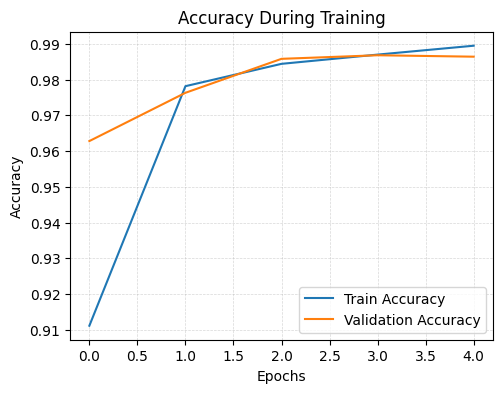

In [20]:
# 绘制准确率图
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy During Training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

ax = plt.gca()
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.5)

plt.show()

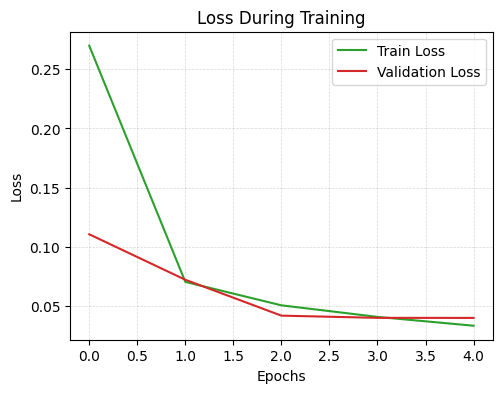

In [21]:
# 绘制损失图
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='tab:green', label='Train Loss')
plt.plot(val_losses, color='tab:red', label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

ax = plt.gca()
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.5)

## 🦾 **9. TensorFlow (CPU 版本) 示例：训练验证模型 + 保存模型**

In [22]:
# 导入所需模块
import os, datetime, pathlib, tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [23]:
# 加载 MNIST 数据集
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [24]:
# 数据预处理（归一化处理）
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255.0
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255.0

In [25]:
# 构建 CNN 模型
model = models.Sequential([
    ## 第一层卷积层
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
    # 采用 32 个卷积核，卷积核大小为 3x3，即提取 32 个特征图；输入图像为单通道 28x28 像素
    ## 第一层池化层（最大池化）
    layers.MaxPooling2D((2,2)),
    ## 第二层卷积层
    layers.Conv2D(64, (3,3), activation='relu'),
    ## 第二层池化层（最大池化）
    layers.MaxPooling2D((2,2)),
    ## 展平层
    layers.Flatten(),
    ## 全连接层（第一层）
    layers.Dense(128, activation='relu'),
    ## 全连接层（第二层）
    layers.Dense(10, activation='softmax')
])

C:\Users\hualo\Programme Files\python-3.11.9-amd64\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# 显示模型结构
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 编译模型
model.compile(optimizer='adam',                        # Adam 优化器（自适应学习率优化算法）
              loss='sparse_categorical_crossentropy',  # 稀疏分类交叉熵损失函数
              metrics=['accuracy'])

In [28]:
# 调试：以下步骤用于接入 TensorBoard，但与 win11 存在兼容性问题；可在 Linux 中安装完 TensorBoard 后再执行以完成调试。
#os.makedirs("logdir", exist_ok=True)
#log_subdir = os.path.join("logdir", 
#                          datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
#tb_callback = tf.keras.callbacks.TensorBoard(log_dir=str(log_subdir),
#                                             histogram_freq=1,
#                                             update_freq='epoch')

#history = model.fit(x_train, y_train, 
#                    epochs=5, batch_size=64,
#                    validation_data=(x_test, y_test),
#                    callbacks=[tb_callback])

In [29]:
# 训练模型
history = model.fit(x_train, y_train, 
                    epochs=5, batch_size=64,
                    validation_data=(x_test, y_test))
# 训练的周期数；每个批次的训练样本

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9542 - loss: 0.1517 - val_accuracy: 0.9839 - val_loss: 0.0489
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9861 - loss: 0.0452 - val_accuracy: 0.9878 - val_loss: 0.0376
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9905 - loss: 0.0306 - val_accuracy: 0.9896 - val_loss: 0.0304
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9921 - loss: 0.0239 - val_accuracy: 0.9891 - val_loss: 0.0317
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9941 - loss: 0.0183 - val_accuracy: 0.9899 - val_loss: 0.0300


In [30]:
# 评估模型
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Accuracy on test set: {test_acc * 100:.2f}%')

Accuracy on test set: 98.99%


In [31]:
# 保存模型
#model.save('mnist_cnn.h5')
model.save('mnist_cnn.keras')

In [32]:
# 进行预测并可视化
predictions = model.predict(x_test[:100])
predicted_labels = np.argmax(predictions, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


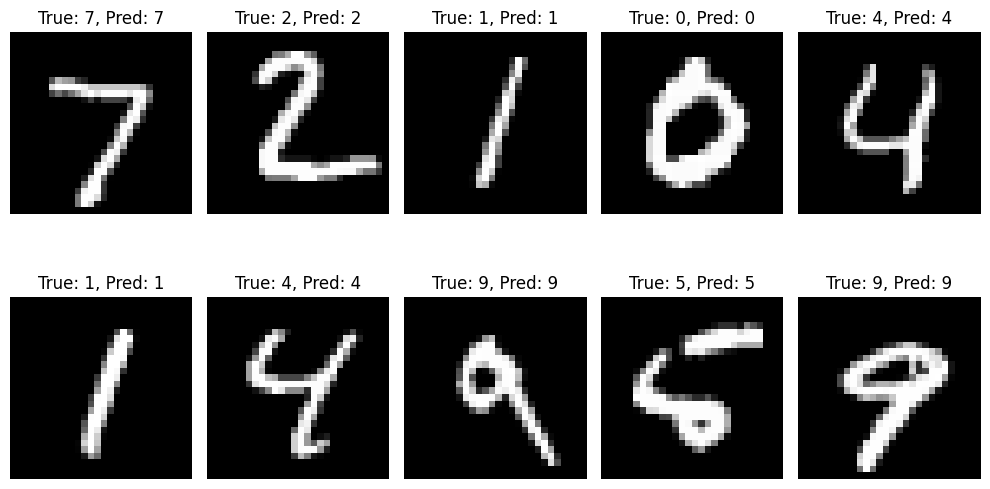

In [33]:
# 显示预测结果
fig, axes = plt.subplots(2, 5, figsize=(10, 6))
axes = axes.flatten()
for img, true_label, pred_label, ax in zip(x_test[:10], y_test[:10], predicted_labels[:10], axes):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'True: {true_label}, Pred: {pred_label}')
    ax.axis('off')
 
plt.tight_layout()
plt.show()

## 🌶 **10. 使用 Flask 应用部署模型**

创建 Flask 应用，将训练好的模型（mnist_cnn.keras 或 mnist_cnn.pth）部署于此应用中，完成前端用户请求的手写数字图片的推理与预测。下图中的 "推理预测" 部分需要前端 HTML 手写板中由用户提交图像数据后才能返回结果。

![flask-run-predict](images/flask-run-predict.png)

## ✍ **11. 创建前端 HTML 手写板用于数字识别验证**

用户在前端 HTML 手写板中绘制 0~9 中任意一个数字，尽可能绘制地大些，以便能更准确地被识别预测。每次绘制完成后，点击 Submit 提交查看预测结果。若想再次尝试，可点击 Clear 清除手写板中的数字，绘制后再次提交即可。预测的推理过程可在 Flask 应用的后端查看（如上图）。

HTML 手写板样例如下所示：

<center><img src="images/html-demo-1.png" style="width:80%"></center>

<center><img src="images/html-demo-2.png" style="width:80%"></center>

## 🔎 **参考链接**

- [一文彻底搞懂CNN —— 模型架构（Model Architecture）](https://mp.weixin.qq.com/s/XW1KxYjmxKZcDBefZr3gJA)
- [一文彻底搞懂CNN —— 卷积和池化（Convolution And Pooling）](https://mp.weixin.qq.com/s?__biz=MzkzMTEzMzI5Ng==&mid=2247490190&idx=1&sn=436a8901375f58df734056df532ab91a&chksm=c26ef891f51971876697c4df30851e23c4073e1874ba2783f13abd620ff6d4ace96d0c985a60&scene=21#wechat_redirect)
- [PyTorch 手写数字识别-深度学习基础分享](https://mp.weixin.qq.com/s/6zmfqMaBnpc2rsI3jYkgLQ)